In [1]:
import pandas as pd
import joblib
from pathlib import Path

# Rede neural multicamandas do scikit-learn
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler

In [2]:
df_train = pd.DataFrame([
    {"renda": 8.0, "historico": 9.0, "aprovado": 1},
    {"renda": 3.0, "historico": 2.0, "aprovado": 0},
    {"renda": 6.0, "historico": 7.0, "aprovado": 1},
    {"renda": 2.0, "historico": 5.0, "aprovado": 0},
    {"renda": 9.0, "historico": 8.0, "aprovado": 1},
    {"renda": 1.0, "historico": 1.0, "aprovado": 0},
    {"renda": 7.0, "historico": 6.0, "aprovado": 1},
    {"renda": 4.0, "historico": 3.0, "aprovado": 0},
])

# Separa entradas da saida esperada
X_train = df_train[["renda", "historico"]]
Y_train = df_train["aprovado"]

print(df_train)

   renda  historico  aprovado
0    8.0        9.0         1
1    3.0        2.0         0
2    6.0        7.0         1
3    2.0        5.0         0
4    9.0        8.0         1
5    1.0        1.0         0
6    7.0        6.0         1
7    4.0        3.0         0


In [3]:
# Normalizar os dados
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

# Cria a rede neural com uma camada oculta de 5 neuronios
# max_iter = numero maximo de ajustes internos
modelo = MLPClassifier(hidden_layer_sizes=(5,), max_iter=2000, random_state=42)

# fit = a rede aprende os padrões
modelo.fit(X_scaled, Y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [4]:
Path("models").mkdir(exist_ok=True)

# Salva o modelo
joblib.dump({"modelo": modelo, "scaler": scaler}, "models/revisao_mlp.joblib")

print("Modelo salvo em models")

Modelo salvo em models


In [5]:
# Novos clientes
df_novo = pd.DataFrame([
    {"renda": 7.5, "historico": 8.0},
    {"renda": 2.0, "historico": 3.5},
    {"renda": 2.0, "historico": 7.5},
    {"renda": 1.0, "historico": 4.5},
])

# Carregar o modelo
state = joblib.load("models/revisao_mlp.joblib")
modelo_prod = state["modelo"]
scaler_prod = state["scaler"]

# Aplicar a mesma normalização sem treinar
X_novo = scaler_prod.transform(df_novo)

previsoes = modelo_prod.predict(X_novo)

df_novo["aprovado_previsto"] = previsoes

df_novo

,renda,historico,aprovado_previsto
0,7.5,8.0,1
1,2.0,3.5,0
2,2.0,7.5,1
3,1.0,4.5,0


In [6]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Carrega o dataset de vinhos de dentro do scikit-learn
wine = load_wine()

# Converte para DataFrame para visualizar
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine["tipo"] = wine.target # 0, 1 ou 2 representam os 3 tipos de uva

print(f"Total de vinhos : {len(df_wine)}")
print(f"Tipos de vinho : {wine.target_names}")
df_wine.head()

Total de vinhos : 178
Tipos de vinho : ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,tipo
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
class MiniMLPClassifier:
    def __init__(self, model_dir="models", nome="mini_mlp"):
        self.model_dir = Path(model_dir)
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.path = self.model_dir / f"{nome}.joblib"

        # fit() ou load()
        self.modelo = None
        self.scaler = None

    def treinar(self, X, Y, neuronios=(10,)):
        self.scaler = MinMaxScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.modelo = MLPClassifier(hidden_layer_sizes=neuronios, max_iter=2000, random_state=42)
        self.modelo.fit(X_scaled, Y)

    def prever(self, X):
        if self.modelo is None:
            self.carregar()

        X_scaled = self.scaler.transform(X)
        return self.modelo.predict(X_scaled)

    def salvar(self):
        # Salva tudo que foi aprendido no fit
        joblib.dump({"modelo": self.modelo, "scaler": self.scaler}, self.path)

    def carregar(self):
        state = joblib.load(self.path)
        self.modelo = state["modelo"]
        self.scaler = state["scaler"]

In [8]:
# Separar trino e teste : 80% para treinar e 20% para avaliar
X_wine = df_wine.drop(columns="tipo")
Y_wine = df_wine["tipo"]

X_wine_train, X_wine_test, Y_wine_train, Y_wine_test = train_test_split(
    X_wine, Y_wine, test_size=0.2, random_state=42
)

# Treina usando a classe 
class_wine = MiniMLPClassifier(nome="vinho")
class_wine.treinar(X_wine_train, Y_wine_train, neuronios=(20, 10))
class_wine.salvar()

# Avalia no conjunto de teste
from sklearn.metrics import accuracy_score

previsoes_wine = class_wine.prever(X_wine_test)
acuracia = accuracy_score(Y_wine_test, previsoes_wine)
print(f"Acuracia no conjunto de teste: {acuracia:.0%}")

Acuracia no conjunto de teste: 100%


In [9]:
# Compara as previsões com os valores reais
df_resultado = X_wine_test.copy()
df_resultado["tipo_real"] = [wine.target_names[i] for i in Y_wine_test]
df_resultado["tipo_previsto"] = [wine.target_names[i] for i in previsoes_wine]
df_resultado["correto"] = df_resultado["tipo_real"] == df_resultado["tipo_previsto"]

df_resultado[["tipo_real", "tipo_previsto", "correto"]].head(10)

,tipo_real,tipo_previsto,correto
19,class_0,class_0,True
45,class_0,class_0,True
140,class_2,class_2,True
30,class_0,class_0,True
67,class_1,class_1,True
16,class_0,class_0,True
119,class_1,class_1,True
174,class_2,class_2,True
109,class_1,class_1,True
141,class_2,class_2,True


Total de imagens: 1797
Tamanho de cada imagem: (8, 8) pixels
Digitos possiveis: [0 1 2 3 4 5 6 7 8 9]


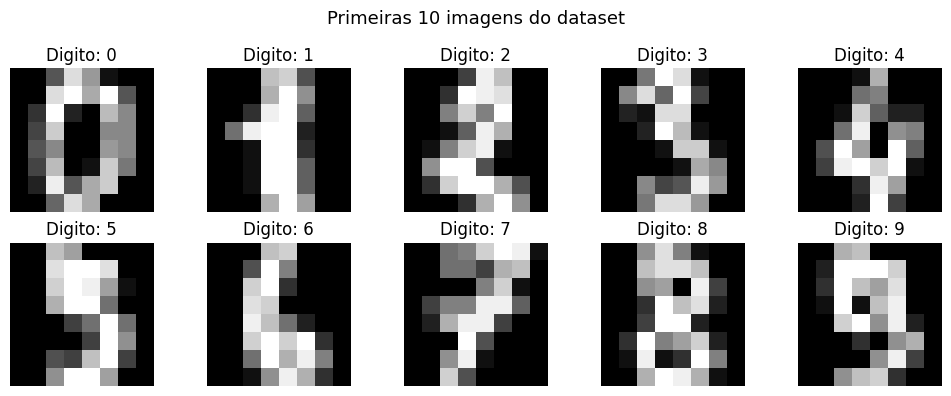

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

print(f"Total de imagens: {len(digits.images)}")
print(f"Tamanho de cada imagem: {digits.images[0].shape} pixels")
print(f"Digitos possiveis: {digits.target_names}")

fig, eixos = plt.subplots(2, 5, figsize=(10,4))
for i, eixo in enumerate(eixos.flat):
    eixo.imshow(digits.images[i], cmap="gray")
    eixo.set_title(f"Digito: {digits.target[i]}")
    eixo.axis("off")

plt.suptitle("Primeiras 10 imagens do dataset", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
X_digits = digits.images.reshape(len(digits.images), -1)
y_digits = digits.target

print(f"Formato de entrada para o modelo: {X_digits.shape}")
print(f"Exemplo de uma imagem como numeros: \n{X_digits[3]}")

# Separar treino e teste
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=22
)


Formato de entrada para o modelo: (1797, 64)
Exemplo de uma imagem como numeros: 
[ 0.  0.  7. 15. 13.  1.  0.  0.  0.  8. 13.  6. 15.  4.  0.  0.  0.  2.
  1. 13. 13.  0.  0.  0.  0.  0.  2. 15. 11.  1.  0.  0.  0.  0.  0.  1.
 12. 12.  1.  0.  0.  0.  0.  0.  1. 10.  8.  0.  0.  0.  8.  4.  5. 14.
  9.  0.  0.  0.  7. 13. 13.  9.  0.  0.]


In [16]:
# Treina a rede neural para reconhecer os digitos
clf_digits = MiniMLPClassifier(nome="digitos")
clf_digits.treinar(X_d_train, y_d_train, neuronios=(64, 64))
clf_digits.salvar()

# Avaliar no conjunto de teste
previsoes_digits = clf_digits.prever(X_d_test)
acuracia_digits = accuracy_score(y_d_test, previsoes_digits)
print(f"Acuracia no reconhecimento de digitos: {acuracia_digits:.0%}")

Acuracia no reconhecimento de digitos: 98%


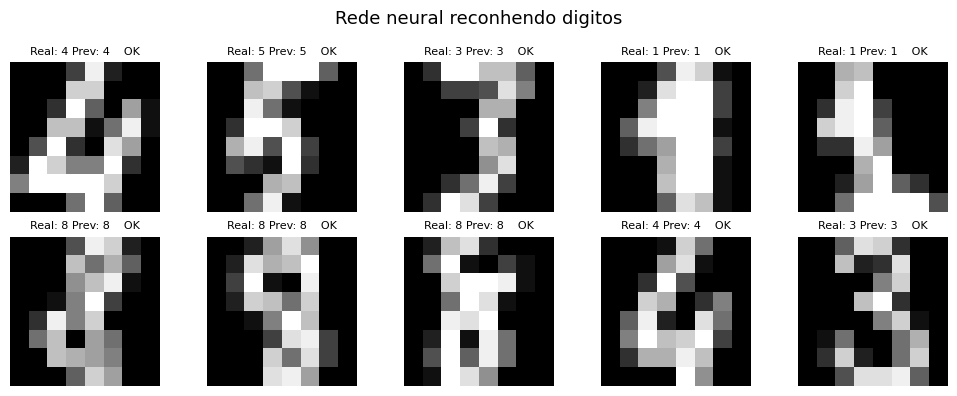

In [17]:
fig, eixos = plt.subplots(2, 5, figsize=(10, 4))
for i, eixo in enumerate(eixos.flat):
    # Recupera a imagem original em formato 8x8
    imagem = X_d_test[i].reshape(8,8)
    real = y_d_test[i]
    previsto = previsoes_digits[i]
    correto = "OK" if real == previsto else "ERRO"

    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(f"Real: {real} Prev: {previsto}    {correto}", fontsize=8)
    eixo.axis("off")

plt.suptitle("Rede neural reconhendo digitos", fontsize=13)
plt.tight_layout()
plt.show()



In [ ]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from io import BytesIO


url = "https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/MnistExamples.png/320px-MnistExamples.png"

# Baixa a imagem
resposta = requests.get(url, timeout=10)
imagem_original = Image.open(BytesIO(resposta.content))

largura, altura = imagem_original.size
imagem_recortada = imagem_original.crop((0, 0, altura, altura)) 

imagem_cinza = imagem_recortada.convert("L")          # escala de cinza
imagem_8x8 = imagem_cinza.resize((8, 8), Image.LANCZOS)  # reduz para 8x8
imagem_inv = ImageOps.invert(imagem_8x8)              # inverte: fundo escuro, digito claro
array = np.array(imagem_inv, dtype=float) / 255 * 16  # normaliza para 0-16

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
ax1.imshow(imagem_cinza, cmap="gray")
ax1.set_title("Imagem original (cinza)")
ax1.axis("off")

ax2.imshow(array, cmap="gray")
ax2.set_title("Versao 8x8 (entrada da IA)")
ax2.axis("off")

plt.tight_layout()
plt.show()

entrada = array.reshape(1, -1)  # transforma em vetor de 64 numeros
previsao = clf_digits.prever(entrada)
print(f"A rede neural disse que o digito e: {previsao[0]}")